In [45]:
import pandas as pd
import seaborn as sns
import numpy as np

In [46]:
import os
print(os.getcwd())

/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/notebooks


In [47]:
df = pd.read_csv("/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/data/ALFRED/simple_outputs/realtime_tcode_balanced.csv")

In [80]:
df_revised = pd.read_csv("/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/data/2026-01-MD.csv")

In [48]:
# Mapping registry copy
mapping = pd.read_csv("/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/data/ALFRED/simple_outputs/mapping_registry copy.csv")

In [49]:
df.head()


,decision_date,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
0,1959-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1959-02-28,0.000000,0.000000,0.000000,0.007336,-0.001250,0.007018,0.011106,0.009947,0.011064,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1959-03-31,0.003877,0.003621,0.010349,-0.003374,0.007310,0.006969,0.013405,0.008628,0.007307,...,0.000437,0.001476,0.004684,0.008147,0.004890,NaN,0.002468,0.001625,-0.009740,NaN
3,1959-04-30,0.006457,0.007325,0.009404,0.019915,0.008321,0.020619,0.006036,0.004894,0.000000,...,-0.001148,0.000292,-0.000022,-0.008147,0.004819,NaN,0.004929,0.004138,-0.014792,NaN
4,1959-05-31,0.006510,0.007029,-0.003622,0.006839,0.000616,0.013514,0.014339,0.014545,0.015652,...,0.001312,0.001760,-0.000022,0.012203,-0.004890,NaN,0.012134,0.006734,0.024929,NaN


In [50]:
map_df = mapping[["mnemonic_hs", "group"]].copy()
map_df = map_df.rename(columns={"mnemonic_hs": "variable"})
map_df["variable"] = map_df["variable"].astype(str)
map_df["group"] = map_df["group"].astype(str).str.strip()

In [51]:
vars_in_data = set(df.columns)
vars_in_map = set(map_df["variable"])

print("Variables in data but not in mapping:")
print(sorted(vars_in_data - vars_in_map))

print("\nVariables in mapping but not in data:")
print(sorted(vars_in_map - vars_in_data))

Variables in data but not in mapping:
['decision_date']

Variables in mapping but not in data:
[]


In [52]:
group_map = dict(zip(map_df["variable"], map_df["group"]))

In [53]:
matched_cols = [c for c in df.columns if c in group_map]

df_matched = df[matched_cols].copy()
print("Shape after matching:", df_matched.shape)

Shape after matching: (805, 126)


In [54]:
df_std = (df_matched - df_matched.mean()) / df_matched.std(ddof=0)

# handle constant series
df_std = df_std.replace([np.inf, -np.inf], np.nan).fillna(0.0)

In [55]:
# --- Load mapping ---
mapping = pd.read_csv("/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/data/ALFRED/simple_outputs/mapping_registry copy.csv")

map_df = mapping[["mnemonic_hs", "group"]].copy()
map_df["mnemonic_hs"] = map_df["mnemonic_hs"].astype(str)

# --- Define group labels ---
group_labels = {
    "1": "Output and Income",
    "2": "Labor Market",
    "3": "Housing",
    "4": "Consumption, Orders and Inventories",
    "5": "Money and Credit",
    "6": "Interest and Exchange Rates",
    "7": "Prices",
    "8": "Stock Market"
}

# Ensure group is string for mapping
map_df["group"] = map_df["group"].astype(str).str.strip()

# Apply labels
map_df["group_name"] = map_df["group"].map(group_labels)

# Drop anything not mapped (e.g. 0 or missing)
map_df = map_df.dropna(subset=["group_name"])

group_map = dict(zip(map_df["mnemonic_hs"], map_df["group_name"]))

# --- Match variables ---
matched_cols = [c for c in df.columns if c in group_map]
df_matched = df[matched_cols].copy()

# --- Standardize ---
df_std = (df_matched - df_matched.mean()) / df_matched.std(ddof=0)
df_std = df_std.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# --- Group averages ---
groups = sorted(set(group_map[c] for c in matched_cols))

group_df = pd.DataFrame(index=df_std.index)
for g in groups:
    cols = [c for c in matched_cols if group_map[c] == g]
    group_df[g] = df_std[cols].mean(axis=1)

print("Groups used:", groups)
group_df.head()

Groups used: ['Consumption, Orders and Inventories', 'Housing', 'Interest and Exchange Rates', 'Labor Market', 'Money and Credit', 'Output and Income', 'Prices', 'Stock Market']


,"Consumption, Orders and Inventories",Housing,Interest and Exchange Rates,Labor Market,Money and Credit,Output and Income,Prices,Stock Market
0,0.000000,0.344409,0.245943,-0.084134,0.000000,0.000000,0.000000,0.000000
1,0.155181,0.344409,0.380785,0.203188,1.977410,0.745510,0.000000,0.050078
2,0.189711,0.349687,0.243383,-0.036690,-0.068793,0.725765,0.087555,0.094291
3,0.320865,0.318635,0.177695,0.223237,-0.054861,0.647008,-0.039991,0.031497
4,-0.070071,0.287979,0.283301,0.066754,0.356741,1.018945,0.035362,0.021665


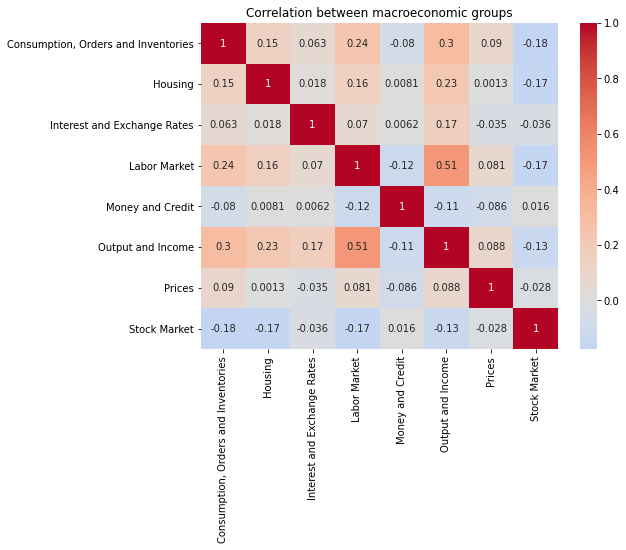

In [57]:
# Correlation
group_corr = group_df.corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(group_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation between macroeconomic groups")
plt.show()

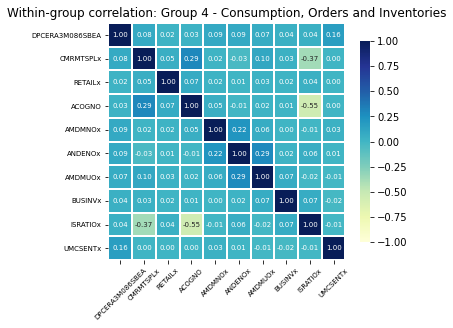

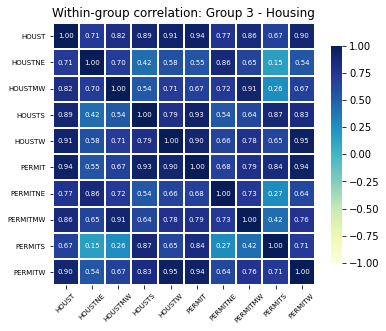

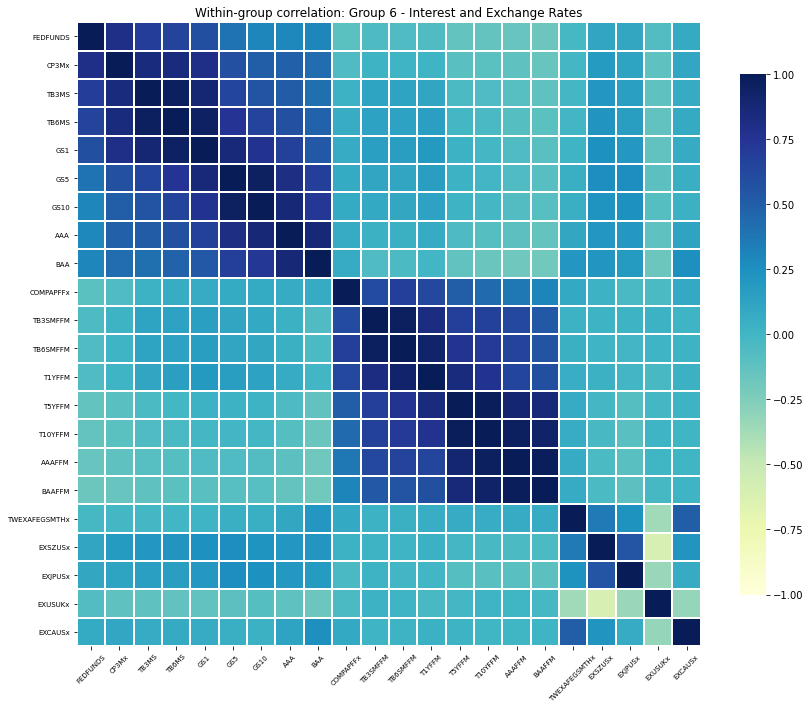

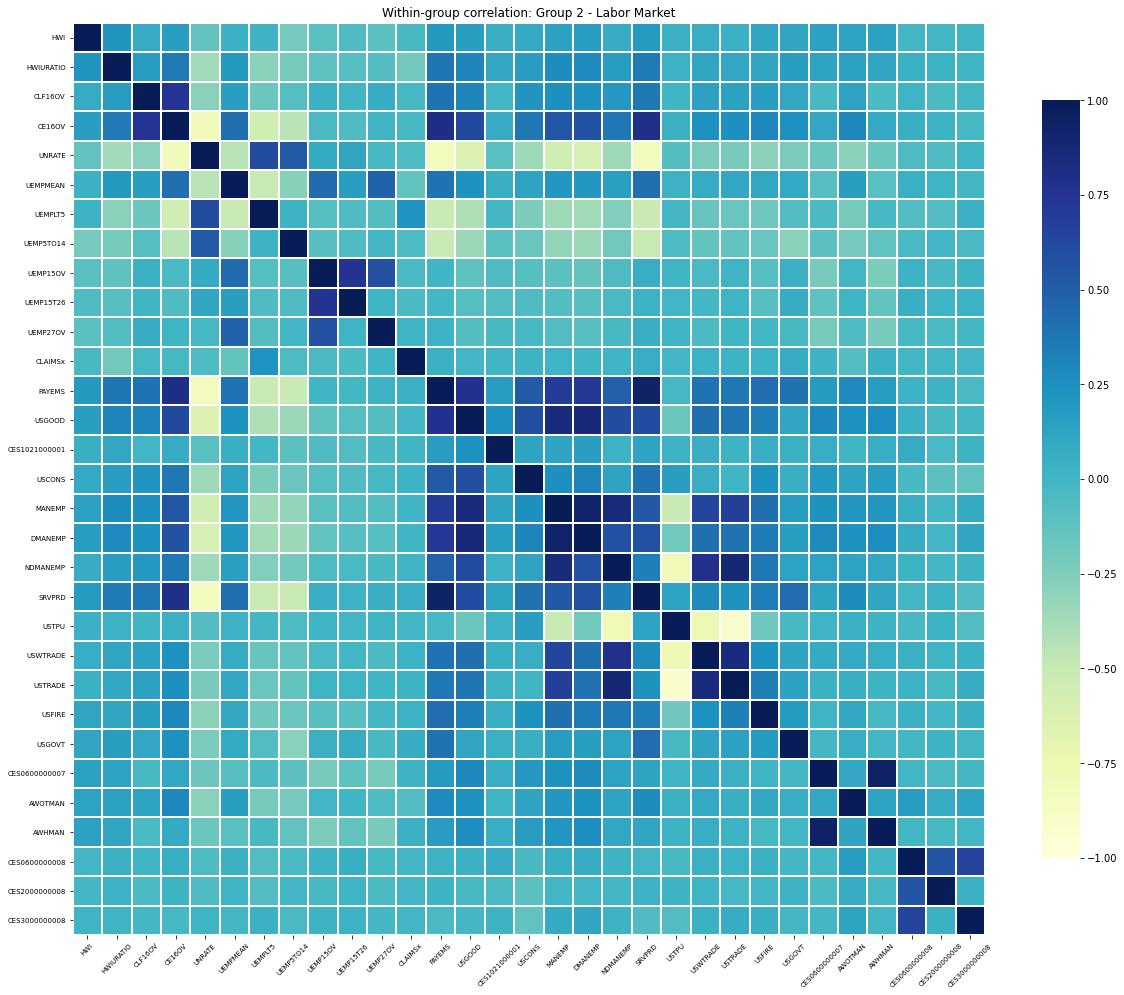

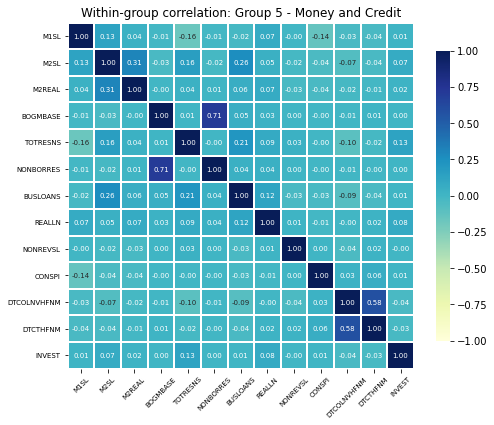

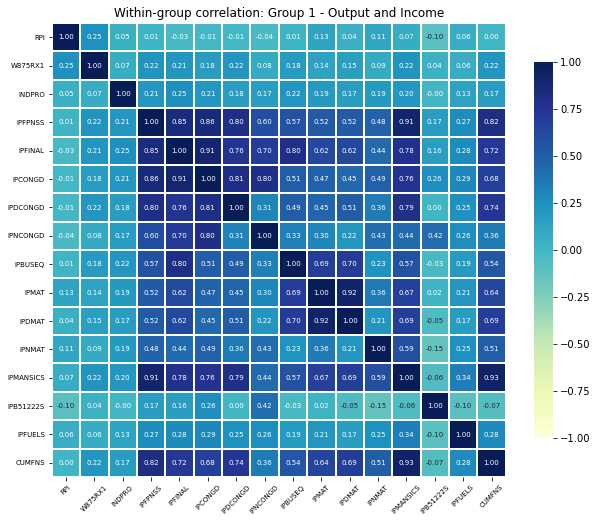

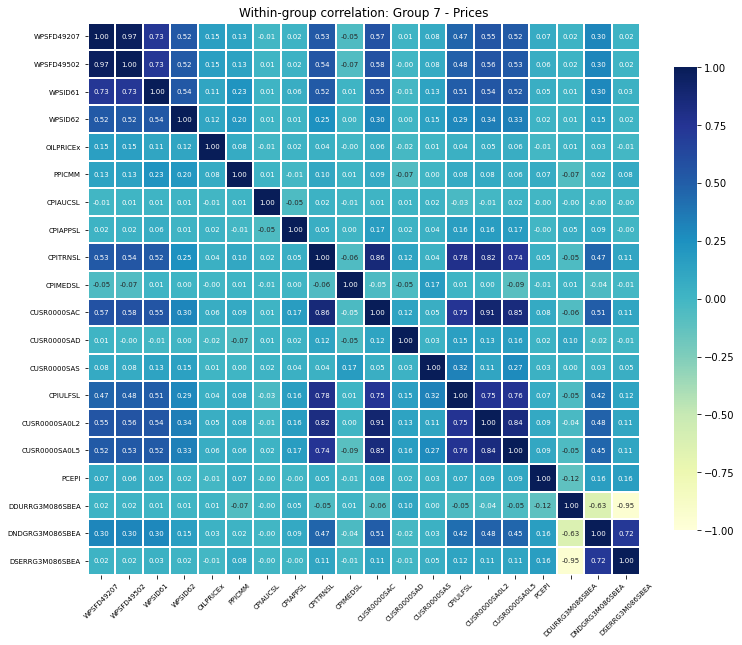

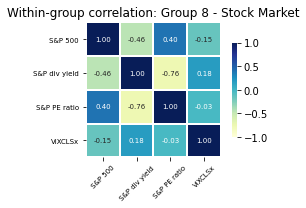

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

# reverse map: group name -> group number
group_labels_reverse = {v: k for k, v in group_labels.items()}

for g in groups:
    cols = [c for c in matched_cols if group_map[c] == g]
    if len(cols) < 2:
        continue

    block = df_std[cols].copy()
    corr = block.corr()

    n = len(corr)
    fig, ax = plt.subplots(figsize=(max(4, n * 0.55), max(3, n * 0.5)))

    sns.heatmap(
        corr,
        ax=ax,
        cmap="YlGnBu",
        vmin=-1,
        vmax=1,
        annot=n <= 20,              # show numbers only for manageable groups
        fmt=".2f",
        annot_kws={"size": 7},
        linewidths=0.3,
        square=True,
        cbar_kws={"shrink": 0.7}
    )

    group_num = group_labels_reverse[g]
    ax.set_title(f"Within-group correlation: Group {group_num} - {g}", fontsize=12)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", rotation=0, labelsize=7)

    plt.tight_layout()
    plt.show()

The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

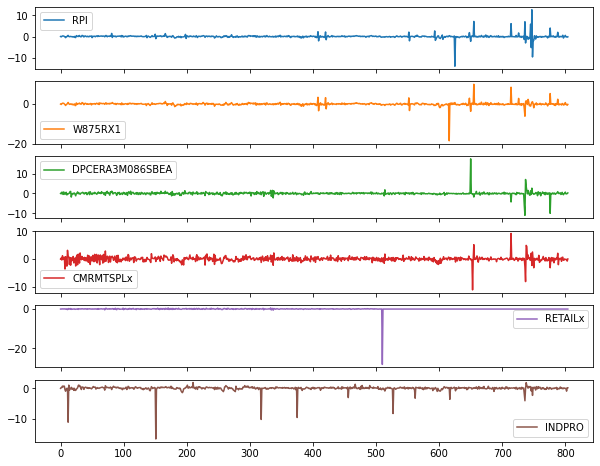

In [64]:
sample_cols = df_std.columns[:6]

df_std[sample_cols].plot(subplots=True, figsize=(10, 8))

<Axes: >

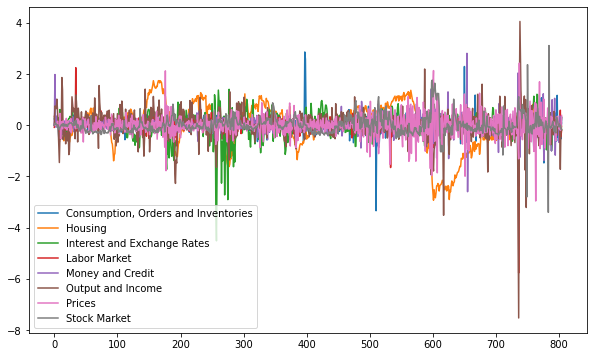

In [63]:
group_df.plot(figsize=(10, 6))

<Axes: >

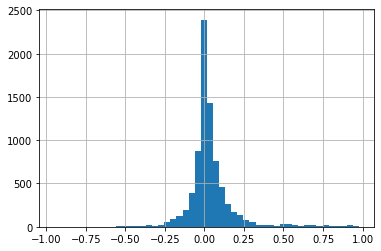

In [66]:
corr = df_std.corr()

pairs = corr.where(
    ~np.tril(np.ones(corr.shape)).astype(bool)
).stack()

pairs.hist(bins=50)

In [67]:
within_group_corr = {}

for g in groups:
    cols = [c for c in matched_cols if group_map[c] == g]
    if len(cols) > 1:
        corr = df_std[cols].corr().values
        within_group_corr[g] = np.nanmean(np.abs(corr[np.triu_indices_from(corr, k=1)]))

pd.Series(within_group_corr)

Consumption, Orders and Inventories    0.071846
Housing                                0.704401
Interest and Exchange Rates            0.264024
Labor Market                           0.182943
Money and Credit                       0.061337
Output and Income                      0.353752
Prices                                 0.188458
Stock Market                           0.329688
dtype: float64

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

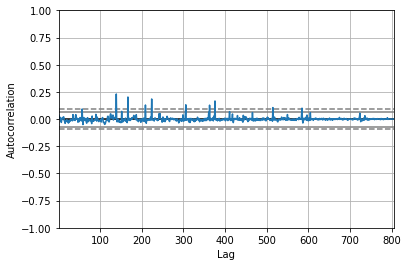

In [68]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(df_std["INDPRO"])

In [69]:
df_std.var().sort_values(ascending=False).head(10)

AWHMAN           1.001244
TB3SMFFM         1.001244
BAAFFM           1.001244
T5YFFM           1.001244
COMPAPFFx        1.001244
HOUST            1.001244
HOUSTMW          1.001244
T10YFFM          1.001244
CES0600000007    1.001244
HOUSTNE          1.001244
dtype: float64

In [70]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

group_pc1 = pd.DataFrame(index=df_std.index)

for g in groups:
    cols = [c for c in matched_cols if group_map[c] == g]
    
    if len(cols) < 2:
        continue
    
    Xg = df_std[cols].dropna()
    
    # Fit PCA
    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(Xg)
    
    # Store back aligned with full index
    pc1_series = pd.Series(pc1.flatten(), index=Xg.index)
    group_pc1[g] = pc1_series

# Optional: standardize PCs (recommended for comparability)
group_pc1 = (group_pc1 - group_pc1.mean()) / group_pc1.std(ddof=0)

print(group_pc1.head())

   Consumption, Orders and Inventories   Housing  Interest and Exchange Rates  \
0                        -7.451326e-15 -0.366900                     0.012711   
1                        -3.453422e-01 -0.366900                    -0.255089   
2                        -7.777872e-02 -0.373001                    -0.002691   
3                        -7.362797e-01 -0.341293                    -0.148715   
4                        -1.966497e-02 -0.315088                    -0.401536   

   Labor Market  Money and Credit  Output and Income        Prices  \
0      0.079870      1.933338e-16      -2.630557e-17 -1.258647e-17   
1     -0.961361     -2.201450e+00      -1.184559e+00 -1.955966e-17   
2     -0.255507     -2.226752e-01      -1.254063e+00  3.271761e-02   
3     -1.104801     -2.175439e-01      -9.308994e-01  1.729491e-01   
4     -1.050330      4.294219e-01      -1.639867e+00 -3.063345e-01   

   Stock Market  
0  7.238007e-17  
1  3.561874e-01  
2 -6.056552e-01  
3 -3.127530e-01  
4 

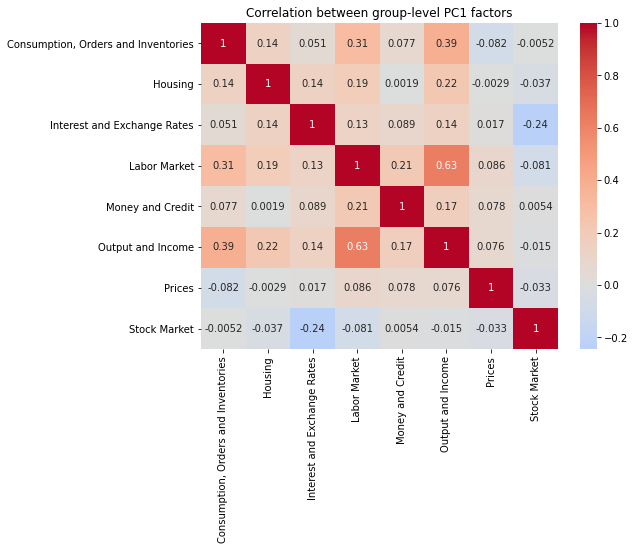

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

pc_corr = group_pc1.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(pc_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation between group-level PC1 factors")
plt.show()

In [72]:
from statsmodels.tsa.stattools import adfuller

adf_results = {}

for col in df.columns:
    series = df[col].dropna()
    if len(series) > 20:
        stat, pval, *_ = adfuller(series)
        adf_results[col] = pval

adf_results = pd.Series(adf_results)

print("Non-stationary (p > 0.05):")
print(adf_results[adf_results > 0.05].head(20))

ValueError: could not convert string to float: '1959-01-31'

In [73]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

# If decision_date is still a column, make it an index
if "decision_date" in df.columns:
    df["decision_date"] = pd.to_datetime(df["decision_date"])
    df = df.set_index("decision_date")

# Keep only numeric columns
df_num = df.select_dtypes(include=["number"]).copy()

adf_results = {}

for col in df_num.columns:
    series = df_num[col].dropna()
    if len(series) > 20:
        stat, pval, *_ = adfuller(series)
        adf_results[col] = pval

adf_results = pd.Series(adf_results)

print("Non-stationary series (p > 0.05):")
print(adf_results[adf_results > 0.05].sort_values(ascending=False).head(20))

Non-stationary series (p > 0.05):
HOUSTNE     0.204418
HOUSTMW     0.145646
PERMITMW    0.093320
PERMITNE    0.086876
PERMIT      0.051397
dtype: float64


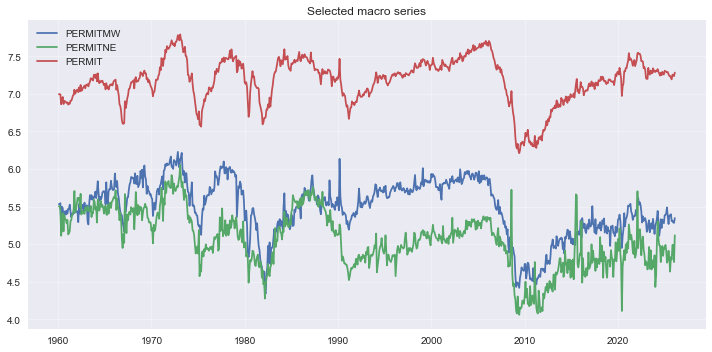

In [78]:
cols = ["PERMITMW", "PERMITNE", "PERMIT"]

plt.figure(figsize=(10, 5))

for c in cols:
    plt.plot(df.index, df[c], label=c)

plt.legend()
plt.title("Selected macro series")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

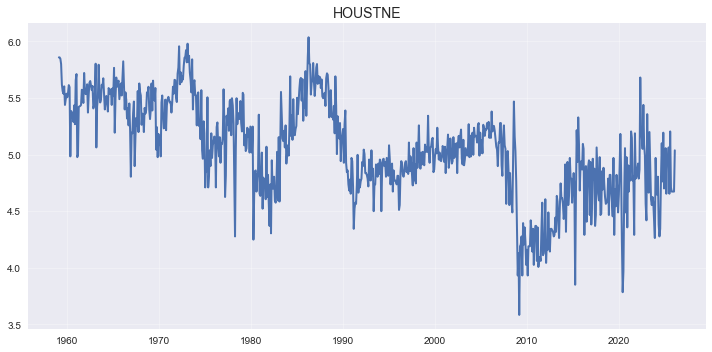

In [74]:
plt.style.use("seaborn-v0_8")

col = "HOUSTNE"

plt.figure(figsize=(10, 5))
plt.plot(df.index, df[col], linewidth=2)

plt.title(f"{col}", fontsize=14)
plt.xlabel("")
plt.ylabel("")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [87]:
if "date" in df_revised.columns:
    df_revised["date"] = pd.to_datetime(df_revised["date"])
    df_revised = df_revised.set_index("date")

<ipython-input-87-105e8d351625>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_revised["date"] = pd.to_datetime(df_revised["date"])


DateParseError: Unknown datetime string format, unable to parse: Transform:, at position 0

In [86]:
df_revised.head()

,date,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
0,Transform:,5.000,5.0,5.000,5.0000,5.00000,5.0000,5.0000,5.0000,5.0000,...,6.000,6.000,6.00,6.00,6.00,2.0,6.0,6.0,6.0000,1.0
1,1/1/1959,2583.560,2426.0,15.188,276676.8154,17689.23968,21.9998,23.6312,22.5507,32.1377,...,18.294,10.152,2.13,2.45,2.04,NaN,6476.0,12298.0,84.2043,NaN
2,2/1/1959,2593.596,2434.8,15.346,278713.9773,17819.01912,22.4306,23.9501,22.7461,32.3734,...,18.302,10.167,2.14,2.46,2.05,NaN,6476.0,12298.0,83.5280,NaN
3,3/1/1959,2610.396,2452.7,15.491,277775.2539,17967.91336,22.7538,24.0951,22.8577,32.3734,...,18.289,10.185,2.15,2.45,2.07,NaN,6508.0,12349.0,81.6405,NaN
4,4/1/1959,2627.446,2470.0,15.435,283362.7075,17978.97983,23.2384,24.4431,23.1926,32.8841,...,18.300,10.221,2.16,2.47,2.08,NaN,6620.0,12484.0,81.8099,NaN


In [88]:
df_revised = df_revised.iloc[1:].copy()
df_revised["date"] = pd.to_datetime(df_revised["date"], errors="coerce")
df_revised = df_revised.dropna(subset=["date"])
df_revised = df_revised.set_index("date").sort_index()
df_revised = df_revised.apply(pd.to_numeric, errors="coerce")

In [89]:
df_revised.head()

,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
date,,,,,,,,,,,,,,,,,,,,,
1959-01-01,2583.560,2426.0,15.188,276676.8154,17689.23968,21.9998,23.6312,22.5507,32.1377,19.7514,...,18.294,10.152,2.13,2.45,2.04,NaN,6476.0,12298.0,84.2043,NaN
1959-02-01,2593.596,2434.8,15.346,278713.9773,17819.01912,22.4306,23.9501,22.7461,32.3734,19.8551,...,18.302,10.167,2.14,2.46,2.05,NaN,6476.0,12298.0,83.5280,NaN
1959-03-01,2610.396,2452.7,15.491,277775.2539,17967.91336,22.7538,24.0951,22.8577,32.3734,20.2439,...,18.289,10.185,2.15,2.45,2.07,NaN,6508.0,12349.0,81.6405,NaN
1959-04-01,2627.446,2470.0,15.435,283362.7075,17978.97983,23.2384,24.4431,23.1926,32.8841,20.3735,...,18.300,10.221,2.16,2.47,2.08,NaN,6620.0,12484.0,81.8099,NaN
1959-05-01,2642.720,2486.4,15.622,285307.2201,18119.82573,23.5885,24.6460,23.4159,33.0413,20.7882,...,18.280,10.238,2.17,2.48,2.08,95.3,6753.0,12646.0,80.7315,NaN


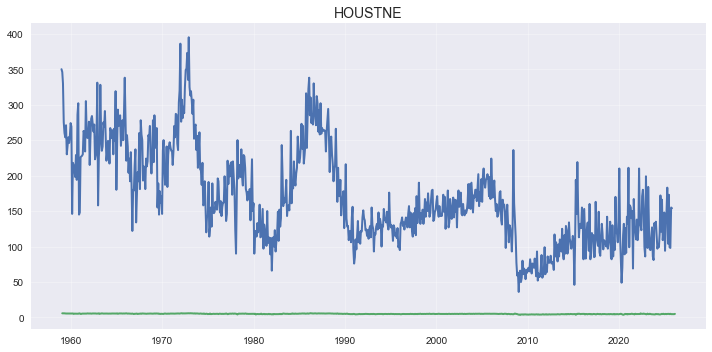

In [91]:
plt.style.use("seaborn-v0_8")

col = "HOUSTNE"

plt.figure(figsize=(10, 5))
plt.plot(df_revised.index, df_revised[col], linewidth=2)
plt.plot(df.index, df[col], linewidth=2)
plt.title(f"{col}", fontsize=14)
plt.xlabel("")
plt.ylabel("")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [92]:
df_revised["HOUSTNE"].head()

date
1959-01-01    350.0
1959-02-01    346.0
1959-03-01    330.0
1959-04-01    275.0
1959-05-01    260.0
Name: HOUSTNE, dtype: float64

In [95]:
df_copy = pd.read_csv("/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/data/ALFRED/simple_outputs/realtime_tcode_balanced.csv")

In [98]:
df_copy["decision_date"] = pd.to_datetime(df_copy["decision_date"], errors="coerce")
df_copy = df_copy.dropna(subset=["decision_date"])
df_copy  = df_copy.set_index("decision_date").sort_index()
df_copy = df_copy.apply(pd.to_numeric, errors="coerce")

In [101]:
df_copy["HOUSTNE"].head()

decision_date
1959-01-31    5.857933
1959-02-28    5.857933
1959-03-31    5.846439
1959-04-30    5.799093
1959-05-31    5.616771
Name: HOUSTNE, dtype: float64

In [104]:
col = "HOUSTNE"

corr = df_copy[col].corr(df_revised[col])
ratio = (df_revised[col] / df_copy[col]).median()

print("Correlation:", corr)
print("Median ratio (scale factor):", ratio)

Correlation: nan
Median ratio (scale factor): nan


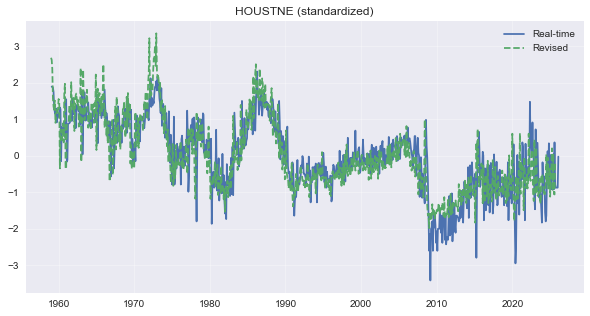

In [105]:
col = "HOUSTNE"

rt = df_copy[col]
rev = df_revised[col]

rt_std = (rt - rt.mean()) / rt.std()
rev_std = (rev - rev.mean()) / rev.std()

plt.figure(figsize=(10, 5))
plt.plot(rt_std, label="Real-time")
plt.plot(rev_std, label="Revised", linestyle="--")

plt.title("HOUSTNE (standardized)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [106]:
from statsmodels.tsa.stattools import adfuller

print("ADF revised:", adfuller(df_revised[col].dropna())[1])
print("ADF real-time:", adfuller(df_copy[col].dropna())[1])

ADF revised: 0.03349447445951611
ADF real-time: 0.20441808356509916


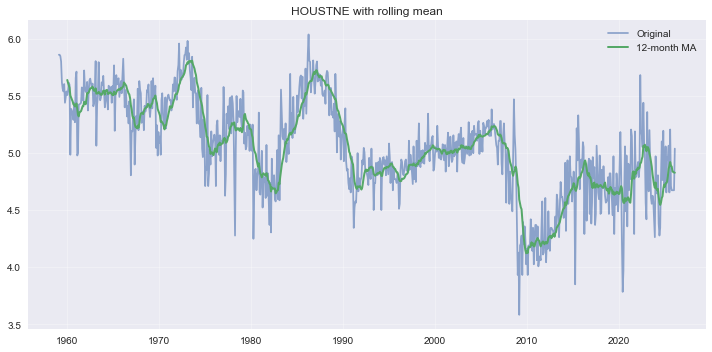

In [107]:
col = "HOUSTNE"

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df.index, df[col], label="Original", alpha=0.6)
ax.plot(df[col].rolling(12).mean(), label="12-month MA", linewidth=2)

ax.set_title(f"{col} with rolling mean")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [79]:
from statsmodels.tsa.stattools import adfuller, kpss

series = df[col].dropna()

adf_p = adfuller(series)[1]
kpss_p = kpss(series, regression='c')[1]

print("ADF p-value:", adf_p)
print("KPSS p-value:", kpss_p)

ADF p-value: 0.20441808356509916
KPSS p-value: 0.01


<ipython-input-79-befaf72d0c1a>:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(series, regression='c')[1]


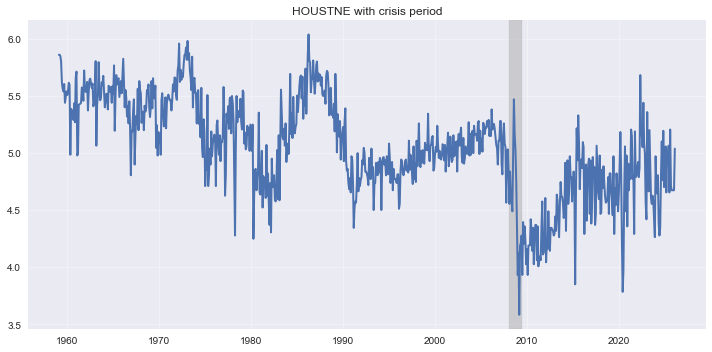

In [77]:
col = "HOUSTNE"

plt.figure(figsize=(10, 5))
plt.plot(df.index, df[col], linewidth=2)

# Example: highlight 2008 crisis
plt.axvspan("2008-01-01", "2009-06-01", color="grey", alpha=0.3)

plt.title(f"{col} with crisis period")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

plt.style.use("seaborn-v0_8")

col = "IN"

plt.figure(figsize=(10, 5))
plt.plot(df.index, df[col], linewidth=2)

plt.title(f"{col}", fontsize=14)
plt.xlabel("")
plt.ylabel("")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

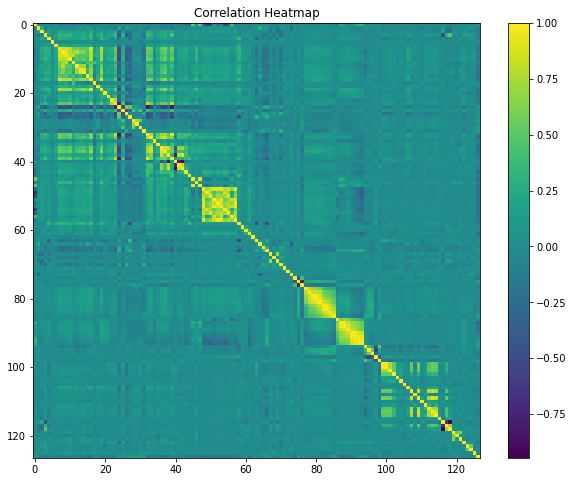

In [ ]:
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

/Users/trineberntsensaether/opt/anaconda3/lib/python3.8/site-packages/seaborn/matrix.py:659: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/trineberntsensaether/opt/anaconda3/lib/python3.8/site-packages/seaborn/matrix.py:659: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


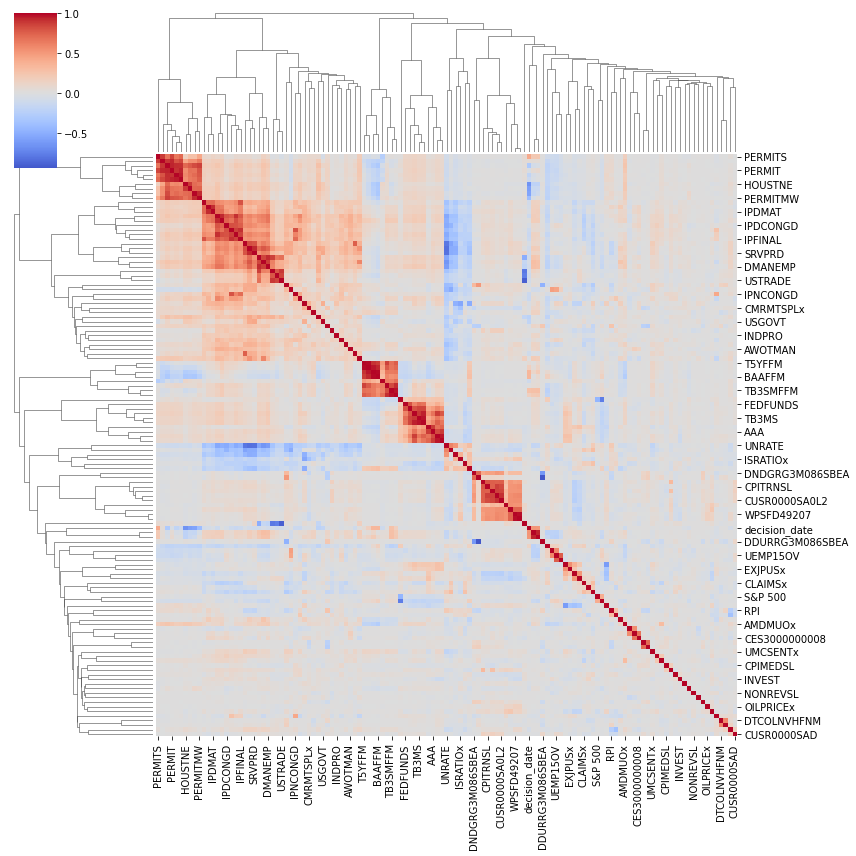

In [ ]:
sns.clustermap(corr, figsize=(12, 12), cmap="coolwarm", center=0)

In [ ]:
for col in df.columns:
    print(col)

decision_date
RPI
W875RX1
DPCERA3M086SBEA
CMRMTSPLx
RETAILx
INDPRO
IPFPNSS
IPFINAL
IPCONGD
IPDCONGD
IPNCONGD
IPBUSEQ
IPMAT
IPDMAT
IPNMAT
IPMANSICS
IPB51222S
IPFUELS
CUMFNS
HWI
HWIURATIO
CLF16OV
CE16OV
UNRATE
UEMPMEAN
UEMPLT5
UEMP5TO14
UEMP15OV
UEMP15T26
UEMP27OV
CLAIMSx
PAYEMS
USGOOD
CES1021000001
USCONS
MANEMP
DMANEMP
NDMANEMP
SRVPRD
USTPU
USWTRADE
USTRADE
USFIRE
USGOVT
CES0600000007
AWOTMAN
AWHMAN
HOUST
HOUSTNE
HOUSTMW
HOUSTS
HOUSTW
PERMIT
PERMITNE
PERMITMW
PERMITS
PERMITW
ACOGNO
AMDMNOx
ANDENOx
AMDMUOx
BUSINVx
ISRATIOx
M1SL
M2SL
M2REAL
BOGMBASE
TOTRESNS
NONBORRES
BUSLOANS
REALLN
NONREVSL
CONSPI
S&P 500
S&P div yield
S&P PE ratio
FEDFUNDS
CP3Mx
TB3MS
TB6MS
GS1
GS5
GS10
AAA
BAA
COMPAPFFx
TB3SMFFM
TB6SMFFM
T1YFFM
T5YFFM
T10YFFM
AAAFFM
BAAFFM
TWEXAFEGSMTHx
EXSZUSx
EXJPUSx
EXUSUKx
EXCAUSx
WPSFD49207
WPSFD49502
WPSID61
WPSID62
OILPRICEx
PPICMM
CPIAUCSL
CPIAPPSL
CPITRNSL
CPIMEDSL
CUSR0000SAC
CUSR0000SAD
CUSR0000SAS
CPIULFSL
CUSR0000SA0L2
CUSR0000SA0L5
PCEPI
DDURRG3M086SBEA
DNDGRG3M086SBEA
